In [1]:
# packages

# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt

import seaborn as sns




In [2]:
t1 = time.time()
df=pd.read_csv('/kaggle/input/finaldata500/final_data_500_follow.csv')
t2 = time.time()
print('Elapsed time [s]: ', np.round(t2-t1,2))
print(len(df))

Elapsed time [s]:  7.03
15980483


In [3]:
import pandas as pd
import numpy as np
import networkx as nx
from collections import deque
import time

In [4]:
# Combine both columns and get unique values
unique_nodes = pd.unique(df[['Follower', 'Target']].values.ravel())

# Count total unique nodes
total_unique_nodes = len(unique_nodes)

print("Total unique nodes:", total_unique_nodes)

Total unique nodes: 5309746


In [5]:
df[df['Follower']==50]

,Follower,Target
8849085,50,933615
8849086,50,636832
8849087,50,205354


In [6]:
# Count how many times each node appears as a Target
target_freq = df['Target'].value_counts().reset_index()
target_freq.columns = ['Target', 'Frequency']

# Sort in descending order by Frequency (optional, already sorted by value_counts)
target_freq_sorted = target_freq.sort_values(by='Frequency', ascending=False)

# Show the top results
print(target_freq_sorted.head())

    Target  Frequency
0  5994113     563916
1  8121005     154446
2  6623784     112376
3   797152     111916
4   645019      99825


In [7]:


t1 = time.time()

# Build directed adjacency list using set for each node
adj_dict = df.groupby('Follower')['Target'].apply(set).to_dict()

# Preview the first 5 keys and a few neighbors each
for k in list(adj_dict.keys())[:5]:
    print(f"{k}: {list(adj_dict[k])[:5]}")

t2 = time.time()
print('Elapsed time [s]: ', np.round(t2-t1,2))


1: [11553, 688136, 8762940, 8762941, 8762942]
2: [1]
3: [645510, 7, 8, 10, 427258]
7: [3, 2164934, 546423]
8: [4732289, 3, 492048, 1041937, 2290325]
Elapsed time [s]:  98.38


In [8]:
# Step 1: Count how many people each Follower follows
follower_freq = df['Follower'].value_counts()

# Step 2: Get top 500 follower node IDs
top_500_followers = follower_freq.head(500).index.tolist()

# Optional: Convert to DataFrame if needed
top_500_df = follower_freq.head(500).reset_index()
top_500_df.columns = ['Follower', 'Number_Followed']

# Preview
print("Top 10 follower node IDs:", top_500_followers[:10])
print("\nTop 5 followers as DataFrame:\n", top_500_df.head())

# Get top 500 follower node IDs as a list
top_500_followers = follower_freq.head(500).index.tolist()

# Preview the first 10
print(top_500_followers[:10])


Top 10 follower node IDs: [5987994, 2654118, 2536943, 3306018, 702514, 1954165, 1378456, 4998576, 2151763, 1097907]

Top 5 followers as DataFrame:
    Follower  Number_Followed
0   5987994              500
1   2654118              495
2   2536943              494
3   3306018              493
4    702514              492
[5987994, 2654118, 2536943, 3306018, 702514, 1954165, 1378456, 4998576, 2151763, 1097907]


In [9]:
# Step 1: Count how many people each follower follows
follower_freq = df['Follower'].value_counts()

# Step 2: Get the 500 followers who follow the fewest people
least_500_followers = follower_freq.sort_values(ascending=True).head(500).reset_index()
least_500_followers.columns = ['Follower', 'Number_Followed']

# Step 3: Print head entries with node ID and how many people they follow
print("📉 Top followers with least followings:\n")
print(least_500_followers.head(10))  # You can change number to see more

# Step 4: Store node IDs in a list
top_500_followers_follow_fewest = least_500_followers['Follower'].tolist()

# Optional: Show a preview of the list
print("\n📌 First 10 node IDs in the list:", top_500_followers_follow_fewest[-10:])


📉 Top followers with least followings:

   Follower  Number_Followed
0   8150039                1
1   2266637                1
2   2266638                1
3   2266639                1
4   2266641                1
5   2266642                1
6   2266644                1
7   2266646                1
8   2266648                1
9   2266649                1

📌 First 10 node IDs in the list: [2264745, 2264746, 2264748, 2264544, 2264752, 2264754, 2264756, 2264757, 2264758, 2264760]


In [10]:
combined_1000_followers = top_500_followers + top_500_followers_follow_fewest

# Final preview
print("\n✅ Combined list size:", len(combined_1000_followers))
print("👀 First 10 combined IDs:", combined_1000_followers[:10])
print("👀 Last 10 combined IDs:", combined_1000_followers[-10:])


✅ Combined list size: 1000
👀 First 10 combined IDs: [5987994, 2654118, 2536943, 3306018, 702514, 1954165, 1378456, 4998576, 2151763, 1097907]
👀 Last 10 combined IDs: [2264745, 2264746, 2264748, 2264544, 2264752, 2264754, 2264756, 2264757, 2264758, 2264760]


**I am choosing only the 4-neighbourhood graph because even within the 4-neighbourhood of a node, millions of nodes and edges are covered. Due to computational limitations, we have restricted our analysis to the 4-neighbourhood and are checking for k11.

As shown below, for the node's neighbourhood graph:

Total nodes visited: 1,621,755

Total edges collected: 7,413,628

These values, in the millions, are for the case where i = 1 and j = 1.******

In [11]:
# Choose range
i = 1
j = 1

# Store feature vectors
vector_rows = []

for idx in range(i, j + 1):
    print(f"\n🚀 Processing node {idx + 1}/{j + 1} (ID: {combined_1000_followers[idx]})")
    top_node =combined_1000_followers[idx]
    t1 = time.time()

    # Step 1: BFS from top_node (your version)
    visited = set()
    edges = []
    node_distance = {}
    queue = deque([(top_node, 0)])
    visited.add(top_node)
    node_distance[top_node] = 0

    while queue:
        current_node, dist = queue.popleft()

        if dist >4:
            continue

        for neighbor in adj_dict.get(current_node, []):
            edges.append((current_node, neighbor))
            if neighbor not in visited:
                visited.add(neighbor)
                node_distance[neighbor] = dist + 1
                queue.append((neighbor, dist + 1))

    df_bfs_edges = pd.DataFrame(edges, columns=['Follower', 'Target'])
    print("Total nodes visited:", len(visited))
    print("Total edges collected:", len(df_bfs_edges))

    # Step 2: In-degree count
   # Treat edges as undirected by counting both Follower and Target appearances
    degree_counts = pd.concat([df_bfs_edges['Follower'],df_bfs_edges['Target']]).value_counts().reset_index()

    degree_counts.columns = ['Node', 'Degree']

    # Sort and get top 500 nodes by degree
    top_500_nodes = degree_counts.sort_values(by='Degree', ascending=False).head(500)['Node'].tolist()

    # Optional: preview top nodes and degrees
    print(degree_counts.head())
    print("\nTop 10 high-degree nodes (undirected):", top_500_nodes[:10])


    # Step 4: Out-degree count
    follower_freq = df_bfs_edges['Follower'].value_counts().reset_index()
    follower_freq.columns = ['Follower', 'Frequency']
    follower_freq_dict = dict(zip(follower_freq['Follower'], follower_freq['Frequency']))

    out_degrees = [follower_freq_dict.get(node, 0) for node in top_500_nodes]
    if len(out_degrees) < 500:
        out_degrees += [0] * (500 - len(out_degrees))  # pad

    print("\n📊 Out-degree of top followed targets (first 10):", out_degrees[:10])

    # Step 5: Iterative filtering
    df_loop_edges = df_bfs_edges.copy()
    for iter_num in range(20):
        df_undirected = pd.concat([
            df_loop_edges[['Follower', 'Target']],
            df_loop_edges.rename(columns={'Follower': 'Target', 'Target': 'Follower'})[['Follower', 'Target']]
        ])
        node_degrees = df_undirected.groupby('Follower').size().reset_index(name='Degree')
        active_nodes = node_degrees[node_degrees['Degree'] >= 10]['Follower'].tolist()
        active_node_set = set(active_nodes)
        df_loop_edges = df_loop_edges[
            df_loop_edges['Follower'].isin(active_node_set) &
            df_loop_edges['Target'].isin(active_node_set)
        ]

        if iter_num == 19:
            print(f"\n🔁 Final Iteration ({iter_num + 1}) Results:")
            print("Total Nodes:", len(active_node_set))
            print("Total Edges:", len(df_loop_edges))

    # Step 6: Build graph and check for cliques
    G = nx.Graph()
    G.add_edges_from(df_loop_edges[['Follower', 'Target']].values)

    try:
        clique_sizes = nx.node_clique_number(G)
        max_clique_size = max(clique_sizes.values()) if clique_sizes else 0
    except:
        max_clique_size = 0

    print("🔎 Max clique size:", max_clique_size)
    clique_exists = 1 if max_clique_size >= 11 else 0

    # Step 7: Create vector [top_node, 500 out-degrees..., clique flag]
    vector = [top_node] + out_degrees + [clique_exists]
    print("📌 Vector sample (first 4 cols):", vector[:4])
    print("📌 Vector sample (last 4 cols):", vector[-4:])

    vector_rows.append(vector)

    t2 = time.time()
    print("⏱️ Time for this node:", round(t2 - t1, 2), "seconds")

# Final output to CSV
vector_df = pd.DataFrame(vector_rows)

# Save the DataFrame with a custom filename
#vector_df.to_csv("name_roll.csv", index=False)

print("\n✅ Saved vectors to 'name_roll.csv'")

print(f"\n✅ Saved vectors for nodes {i} to {j} to 'name_roll_{i}_to_{j}.csv'")


🚀 Processing node 2/2 (ID: 2654118)
Total nodes visited: 1621755
Total edges collected: 7413628
      Node  Degree
0  8762941   25807
1   645019   15921
2    16482   14826
3  8762946   13886
4    38253   13566

Top 10 high-degree nodes (undirected): [8762941, 645019, 16482, 8762946, 38253, 7831973, 8762942, 12852, 1931522, 124907]

📊 Out-degree of top followed targets (first 10): [0, 266, 21, 0, 27, 0, 0, 167, 1, 155]

🔁 Final Iteration (20) Results:
Total Nodes: 112293
Total Edges: 4933662
🔎 Max clique size: 11
📌 Vector sample (first 4 cols): [2654118, 0, 266, 21]
📌 Vector sample (last 4 cols): [14, 5, 0, 1]
⏱️ Time for this node: 172.59 seconds

✅ Saved vectors to 'name_roll.csv'

✅ Saved vectors for nodes 1 to 1 to 'name_roll_1_to_1.csv'


In [12]:

# Load the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [13]:
dataset = pd.read_csv('/kaggle/input/bda1000points/BDA1000pts.csv',header=None,skiprows=1)


In [14]:
dataset

,0,1,2,3,4,5,6,7,8,9,...,492,493,494,495,496,497,498,499,500,501
0,2265338,430,370,428,483,203,367,266,282,431,...,247,234,241,248,215,172,241,245,52,0
1,2265339,203,430,266,370,428,285,105,396,395,...,365,9,376,31,90,227,340,281,311,1
2,2265345,430,266,370,203,428,0,285,396,483,...,290,365,85,397,345,392,277,376,0,0
3,2265347,0,430,266,203,370,428,185,396,285,...,443,416,441,422,449,351,417,451,441,1
4,2265592,203,430,266,370,428,285,105,396,395,...,365,9,376,31,90,227,340,281,311,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,847108,0,266,21,0,27,0,167,1,0,...,1,0,0,2,0,5,0,15,0,1
956,738841,0,266,21,0,27,0,1,167,0,...,1,477,3,0,1,0,1,0,0,1
957,498683,0,266,21,0,27,0,1,167,0,...,0,1,1,0,0,0,0,0,2,1
958,4354644,0,266,21,0,27,0,167,1,0,...,7,2,0,2,282,0,1,0,0,1


In [15]:
unique_dataset = dataset.drop_duplicates(subset=dataset.columns[0])

# Optionally, reset the index
dataset = unique_dataset.reset_index(drop=True)


In [16]:
# Get unique values in column 0 (by index)
unique_values = dataset.iloc[:, 0].unique()

# Count how many unique values there are
num_unique = len(unique_values)

print("Number of unique values:", num_unique)

Number of unique values: 952


In [17]:
len(dataset)

952

In [18]:

# Drop the first column by position, not by name
dataset = dataset.drop(dataset.columns[0], axis=1)

# Reset column names to start from 0
dataset.columns = range(dataset.shape[1])

In [19]:
df=dataset

In [20]:
df

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,430,370,428,483,203,367,266,282,431,395,...,247,234,241,248,215,172,241,245,52,0
1,203,430,266,370,428,285,105,396,395,0,...,365,9,376,31,90,227,340,281,311,1
2,430,266,370,203,428,0,285,396,483,483,...,290,365,85,397,345,392,277,376,0,0
3,0,430,266,203,370,428,185,396,285,13,...,443,416,441,422,449,351,417,451,441,1
4,203,430,266,370,428,285,105,396,395,0,...,365,9,376,31,90,227,340,281,311,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,0,266,21,0,27,0,167,1,0,396,...,1,0,0,2,0,5,0,15,0,1
948,0,266,21,0,27,0,1,167,0,155,...,1,477,3,0,1,0,1,0,0,1
949,0,266,21,0,27,0,1,167,0,155,...,0,1,1,0,0,0,0,0,2,1
950,0,266,21,0,27,0,167,1,0,155,...,7,2,0,2,282,0,1,0,0,1


In [21]:
df = df.sample(frac=1).reset_index(drop=True)
df

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,0,266,21,0,27,0,1,167,0,155,...,0,1,0,2,28,0,3,477,0,1
1,0,266,21,0,27,0,0,167,1,155,...,1,1,0,2,229,0,5,48,0,1
2,203,266,0,430,396,127,105,0,155,134,...,432,432,433,417,451,433,390,438,447,0
3,203,266,0,396,0,127,167,21,0,76,...,470,0,348,375,2,482,468,408,475,0
4,0,266,21,0,27,0,1,167,0,155,...,0,1,0,2,1,15,33,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,0,266,21,0,27,0,0,167,1,155,...,27,2,40,2,0,15,0,0,66,1
948,203,266,0,396,0,127,167,21,0,76,...,470,0,348,375,2,482,468,408,475,0
949,0,266,21,0,27,0,1,167,0,155,...,2,0,0,11,299,217,1,2,282,1
950,203,266,0,430,105,396,167,0,134,21,...,366,426,417,2,403,438,457,378,338,0


In [22]:
# Count of unique values in column 0
unique_count = df[500].nunique()

print(f"Unique value count in column 0: {unique_count}")

Unique value count in column 0: 2


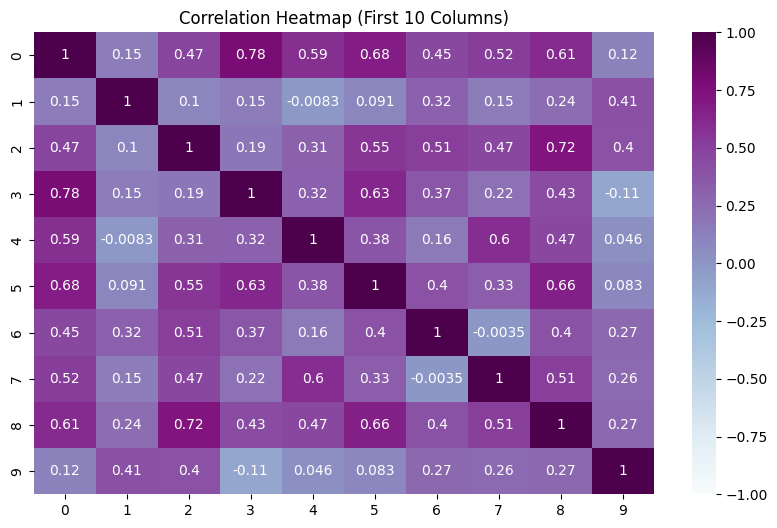

In [23]:
# Select only the first 10 columns
df_subset = df.iloc[:, :10]

# Compute correlation matrix for the subset
corr = df_subset.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            cmap="BuPu",
            vmin=-1,
            vmax=1,
            annot=True)
plt.title("Correlation Heatmap (First 10 Columns)")
plt.show()

**Based on the exploratory analysis, we can conclude that there are some correlated features within the dataset. As a result, the model might benefit from applying Principal Component Analysis (PCA) to reduce the dimensionality of the data.******

In [24]:
X = df.iloc[:, 0:-1].values
y = df.iloc[:, -1].values

In [25]:
X


array([[  0, 266,  21, ...,   3, 477,   0],
       [  0, 266,  21, ...,   5,  48,   0],
       [203, 266,   0, ..., 390, 438, 447],
       ...,
       [  0, 266,  21, ...,   1,   2, 282],
       [203, 266,   0, ..., 457, 378, 338],
       [  0, 266,  21, ...,   0,   1,   0]])

In [26]:
y

array([1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [28]:
#scaling and centering the data
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

**There are several ways to determine the optimal value for the n_components parameter when applying PCA effectively. Two commonly used data visualizations—the explained variance plot and the cumulative explained variance plot—can help identify the ideal number of principal components needed to capture the most significant information from the original dataset.**

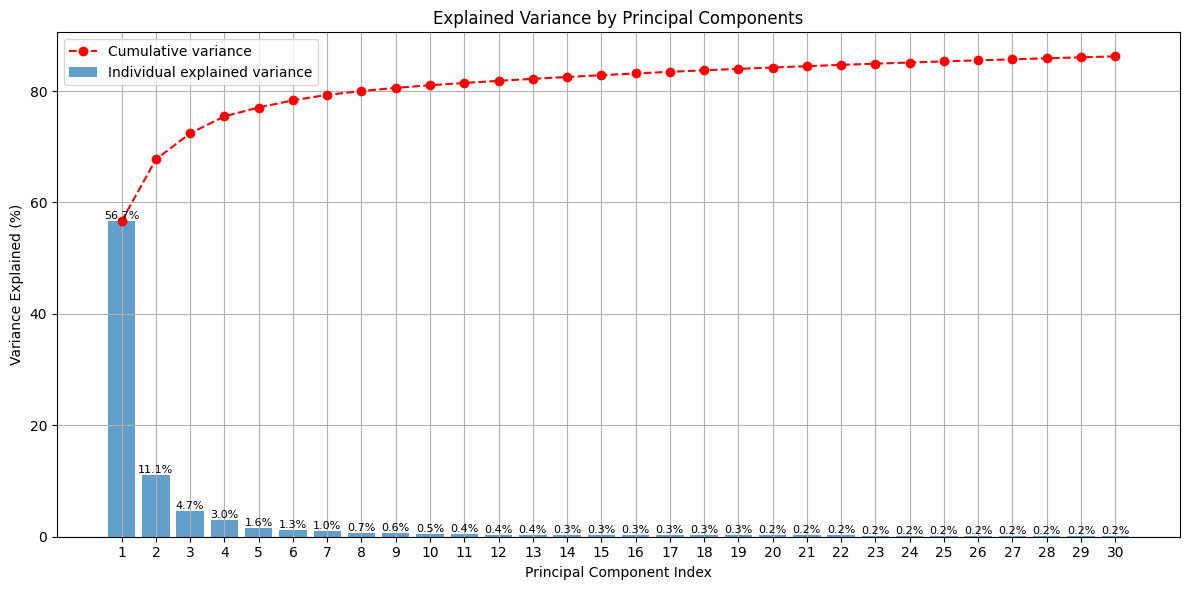

In [29]:
# Calculate the covariance matrix and eigen decomposition
cov_mat = np.cov(X_train_scaled.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# Convert complex values to real
eigen_vals = np.real(eigen_vals)
eigen_vecs = np.real(eigen_vecs)



# Sort eigenvalues in descending order
eigen_vals = np.sort(eigen_vals)[::-1]

# Calculate explained variance ratio for each eigenvalue
exp_var = [(i / np.sum(eigen_vals)) * 100 for i in eigen_vals]
cum_exp_var = np.cumsum(exp_var)

# Set how many principal components to display (e.g., 30 for clarity)
top_k = 30

# Plotting the individual explained variance
plt.figure(figsize=(12, 6))
bars = plt.bar(range(1, top_k + 1), exp_var[:top_k], align='center', label='Individual explained variance', alpha=0.7)

# Add labels on top of each bar
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{exp_var[i]:.1f}%',
             ha='center', va='bottom', fontsize=8)

# Plotting the cumulative explained variance (optional)
plt.plot(range(1, top_k + 1), cum_exp_var[:top_k], color='red', marker='o', linestyle='--', label='Cumulative variance')

# Labels and formatting
plt.ylabel('Variance Explained (%)')
plt.xlabel('Principal Component Index')
plt.title('Explained Variance by Principal Components')
plt.xticks(ticks=list(range(1, top_k + 1)))
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

**80 pecentage of variance is captured by first 7 principle components**

Number of components explaining ≥ 99% variance: 263


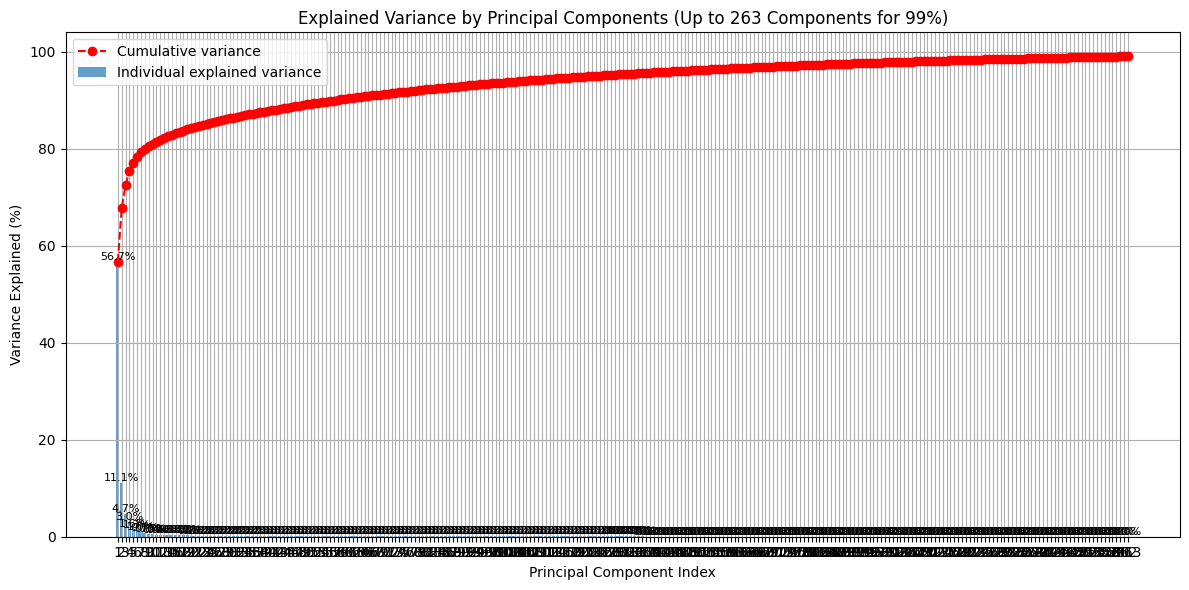

In [30]:
# Compute covariance matrix and perform eigen decomposition
cov_mat = np.cov(X_train_scaled.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# Add this:
eigen_vals = np.real(eigen_vals)
eigen_vecs = np.real(eigen_vecs)

# Sort eigenvalues in descending order
eigen_vals = np.sort(eigen_vals)[::-1]

# Calculate individual explained variance
exp_var = [(i / np.sum(eigen_vals)) * 100 for i in eigen_vals]

# Calculate cumulative explained variance
cum_exp_var = np.cumsum(exp_var)

# Find the number of components required to explain at least 99% variance
top_k = np.argmax(cum_exp_var >= 99) + 1
print(f"Number of components explaining ≥ 99% variance: {top_k}")

# Plotting
plt.figure(figsize=(12, 6))
bars = plt.bar(range(1, top_k + 1), exp_var[:top_k], align='center', label='Individual explained variance', alpha=0.7)
plt.plot(range(1, top_k + 1), cum_exp_var[:top_k], color='red', marker='o', linestyle='--', label='Cumulative variance')

# Annotate bars with variance values
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{exp_var[i]:.1f}%', 
             ha='center', va='bottom', fontsize=8)

plt.ylabel('Variance Explained (%)')
plt.xlabel('Principal Component Index')
plt.title(f'Explained Variance by Principal Components (Up to {top_k} Components for 99%)')
plt.xticks(range(1, top_k + 1))
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Scree Plot')

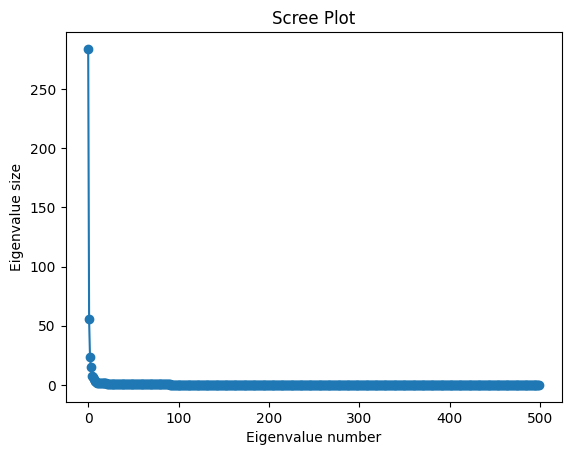

In [31]:
# generate scree plot
pca = PCA()
X_train = pca.fit_transform(X_train_scaled)
explained_variance = pca.explained_variance_ratio_
plt.plot(pca.explained_variance_, marker='o')
plt.xlabel("Eigenvalue number")
plt.ylabel("Eigenvalue size")
plt.title("Scree Plot")

**#  PCA with 2 components******

In [32]:

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_train_scaled)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2'])

# Convert y_train to DataFrame and reset the index
y_train = pd.DataFrame(y_train)  # Convert y_train to DataFrame if it's not already
y_train.reset_index(drop=True, inplace=True)  # Reset index

# Add target to PCA DataFrame
pca_df['target'] = y_train

# Now pca_df contains PCA components and target labels
final_pca_df = pca_df

In [33]:
final_pca_df

,principal component 1,principal component 2,target
0,-16.815566,-0.247137,1
1,15.175958,-14.757343,0
2,22.272342,6.244168,1
3,-17.058468,-0.306179,1
4,15.175958,-14.757343,0
...,...,...,...
756,20.888073,6.081329,1
757,-17.070658,-0.295165,1
758,-16.848845,-0.329074,1
759,-16.921818,-0.280836,1


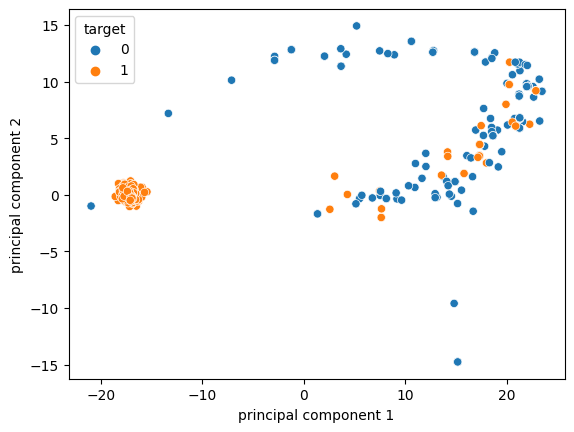

In [34]:
ax = sns.scatterplot(x =final_pca_df.iloc[:,0], y = final_pca_df.iloc[:,1],
hue = 'target',
data=final_pca_df,
legend=True)
plt.show()

**PCA with 3 components**

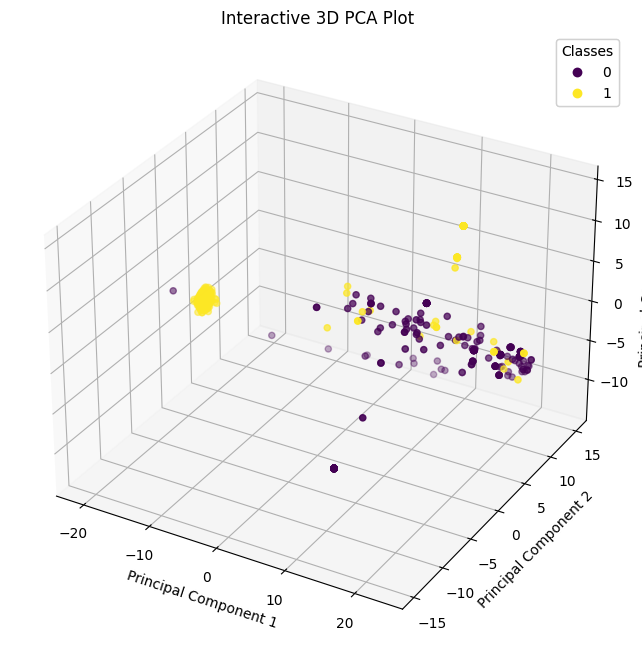

In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd


pca = PCA(n_components=3)
principalComponents = pca.fit_transform(X_train_scaled)

# Create DataFrame for the PCA results
pca_df = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2', 'principal component 3'])

# Reset the index of pca_df and y_train to ensure they match
pca_df.reset_index(drop=True, inplace=True)
y_train = pd.DataFrame(y_train)
y_train.reset_index(drop=True, inplace=True)

# Add target to the PCA DataFrame
final_pca_df = pca_df
final_pca_df['target'] = y_train

# Create the figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(final_pca_df['principal component 1'], final_pca_df['principal component 2'], final_pca_df['principal component 3'], c=final_pca_df['target'], cmap='viridis')

# Labels and title
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('Interactive 3D PCA Plot')

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

# Enabling interactive rotation
plt.ion()

# Show the plot
plt.show()


******PCA with 3 components, interactive 3d plot**** 

In [36]:
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA

# Perform PCA with 3 components
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(X_train_scaled)

# Create DataFrame for the PCA results
pca_df = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2', 'principal component 3'])

# Reset the index of pca_df and y_train to ensure they match
pca_df.reset_index(drop=True, inplace=True)
y_train = pd.DataFrame(y_train)
y_train.reset_index(drop=True, inplace=True)

# Add target to the PCA DataFrame
pca_df['target'] = y_train

# Create the interactive 3D scatter plot
fig = px.scatter_3d(pca_df, x='principal component 1', y='principal component 2', z='principal component 3', color='target',
                    title='Interactive 3D PCA Plot', labels={'target': 'Classes'})

# Show the plot
fig.show()


**PCA with 3 components, interactive 3d plot ****** 
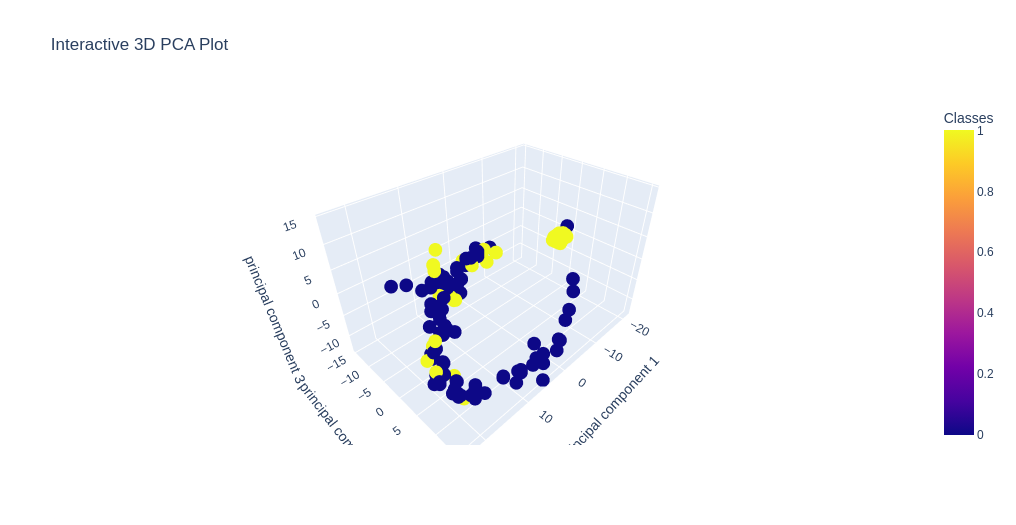

**PCA with five components**

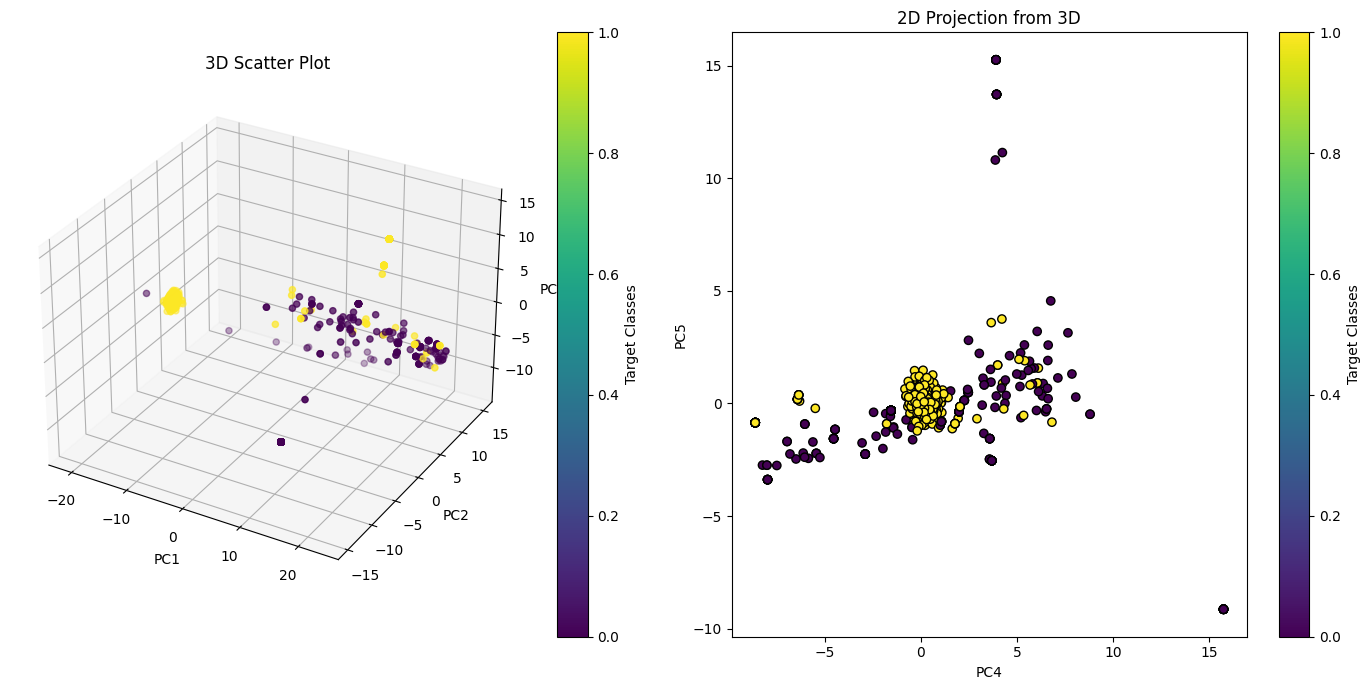

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 5 components
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(X_train_scaled)

# Create DataFrame for the PCA results
pca_df = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2', 'principal component 3', 'principal component 4', 'principal component 5'])

# Reset the index of pca_df and y_train to ensure they match
pca_df.reset_index(drop=True, inplace=True)
y_train = pd.DataFrame(y_train)
y_train.reset_index(drop=True, inplace=True)

# Add target to the PCA DataFrame
pca_df['target'] = y_train

# Extract first 3 components for 3D data
pca_3d = pca_df[['principal component 1', 'principal component 2', 'principal component 3']]

# Extract last 2 components for 2D data
pca_2d = pca_df[['principal component 4', 'principal component 5']]

# Create a figure with subplots (side by side)
fig = plt.figure(figsize=(14, 7))

# 3D plot (left side)
ax1 = fig.add_subplot(121, projection='3d')
sc = ax1.scatter(pca_3d['principal component 1'], pca_3d['principal component 2'], pca_3d['principal component 3'], c=pca_df['target'], cmap='viridis')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('3D Scatter Plot')

# 2D plot (right side)
ax2 = fig.add_subplot(122)
sc2 = ax2.scatter(pca_2d['principal component 4'], pca_2d['principal component 5'], c=pca_df['target'], cmap='viridis', edgecolors='k')
ax2.set_xlabel('PC4')
ax2.set_ylabel('PC5')
ax2.set_title('2D Projection from 3D')

# Add colorbar for both plots
fig.colorbar(sc, ax=ax1, label='Target Classes')
fig.colorbar(sc2, ax=ax2, label='Target Classes')

plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Ensure y is a 1D array
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

# List of PCA components to evaluate
pca_components = [263, 50, 30, 20, 7]

for n in pca_components:
    print(f"\n--- PCA with {n} Components ---")
    
    # Apply PCA
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Train Logistic Regression
    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_train_pca, y_train)
    
    # Evaluate
    y_train_pred = log_reg.predict(X_train_pca)
    y_test_pred = log_reg.predict(X_test_pca)
    
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Confusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred))



--- PCA with 263 Components ---
Train Accuracy: 0.9986859395532195
Test Accuracy: 0.9476439790575916
Confusion Matrix (Test):
 [[ 76   8]
 [  2 105]]

--- PCA with 50 Components ---
Train Accuracy: 0.9829172141918529
Test Accuracy: 0.9424083769633508
Confusion Matrix (Test):
 [[ 77   7]
 [  4 103]]

--- PCA with 30 Components ---
Train Accuracy: 0.9724047306176085
Test Accuracy: 0.9319371727748691
Confusion Matrix (Test):
 [[ 75   9]
 [  4 103]]

--- PCA with 20 Components ---
Train Accuracy: 0.9632063074901446
Test Accuracy: 0.9267015706806283
Confusion Matrix (Test):
 [[ 75   9]
 [  5 102]]

--- PCA with 7 Components ---
Train Accuracy: 0.9487516425755584
Test Accuracy: 0.9267015706806283
Confusion Matrix (Test):
 [[ 76   8]
 [  6 101]]


**MAximum  test accuracy is coming for pca=30, but for plotting purpose, we are choosing 2nd highest test accuracy which is for PCA=7**

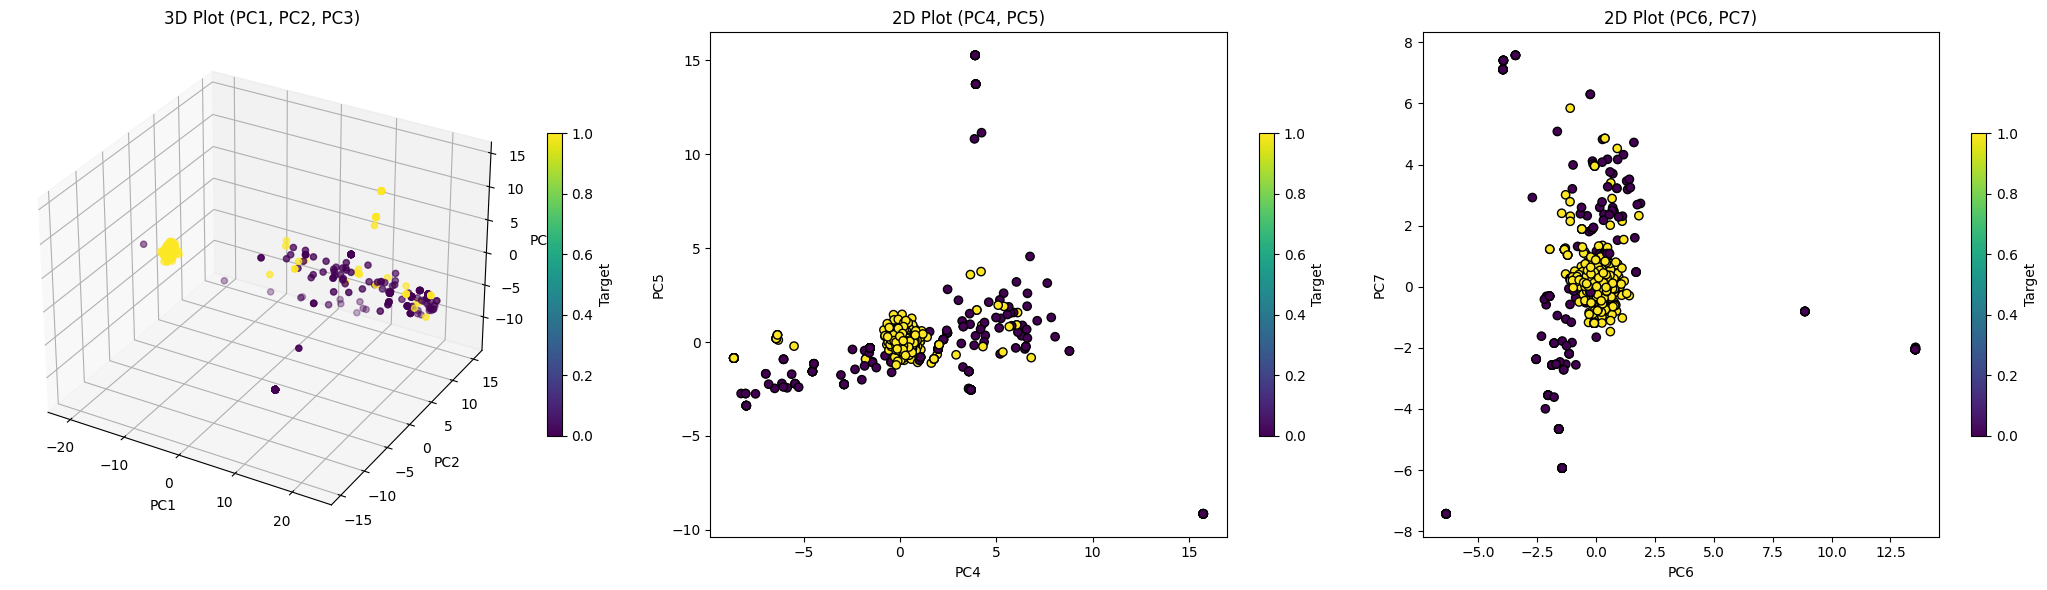

In [39]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 7 components
pca = PCA(n_components=7)
principalComponents = pca.fit_transform(X_train_scaled)

# Create DataFrame for the PCA results
pca_df = pd.DataFrame(data=principalComponents, columns=[
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])

# Reset the index of pca_df and y_train to ensure they match
pca_df.reset_index(drop=True, inplace=True)
y_train = pd.DataFrame(y_train).reset_index(drop=True)

# Add target to the PCA DataFrame
pca_df['target'] = y_train

# Create a figure with 3 subplots (side by side)
fig = plt.figure(figsize=(21, 6))

# 1. 3D plot (PC1, PC2, PC3)
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
                  c=pca_df['target'].values.ravel(), cmap='viridis')
ax1.set_title('3D Plot (PC1, PC2, PC3)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# 2. 2D plot (PC4, PC5)
ax2 = fig.add_subplot(132)
sc2 = ax2.scatter(pca_df['PC4'], pca_df['PC5'],
                  c=pca_df['target'].values.ravel(), cmap='viridis', edgecolors='k')
ax2.set_title('2D Plot (PC4, PC5)')
ax2.set_xlabel('PC4')
ax2.set_ylabel('PC5')

# 3. 2D plot (PC6, PC7)
ax3 = fig.add_subplot(133)
sc3 = ax3.scatter(pca_df['PC6'], pca_df['PC7'],
                  c=pca_df['target'].values.ravel(), cmap='viridis', edgecolors='k')
ax3.set_title('2D Plot (PC6, PC7)')
ax3.set_xlabel('PC6')
ax3.set_ylabel('PC7')

# Colorbars for each plot
fig.colorbar(sc1, ax=ax1, shrink=0.6, label='Target')
fig.colorbar(sc2, ax=ax2, shrink=0.6, label='Target')
fig.colorbar(sc3, ax=ax3, shrink=0.6, label='Target')

plt.tight_layout()
plt.show()


**logistic model along with 7 principal components, as 80% variance is captured by top 7 principal components******

Train Accuracy: 0.9487516425755584
Test Accuracy: 0.9267015706806283

Confusion Matrix (Test):
 [[ 76   8]
 [  6 101]]


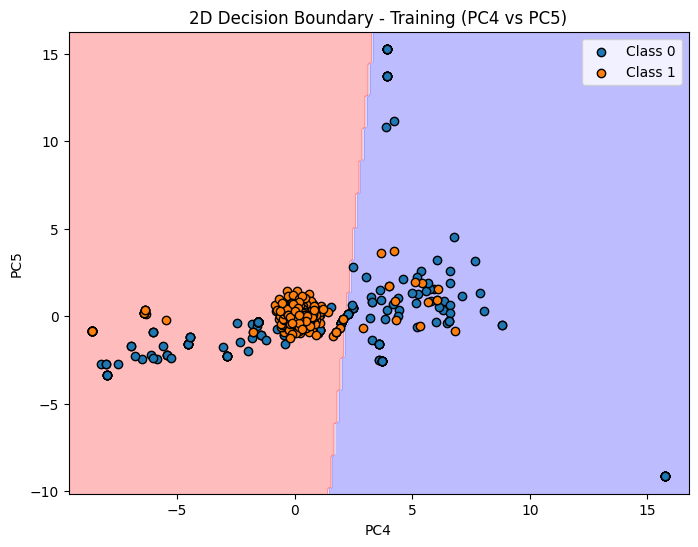

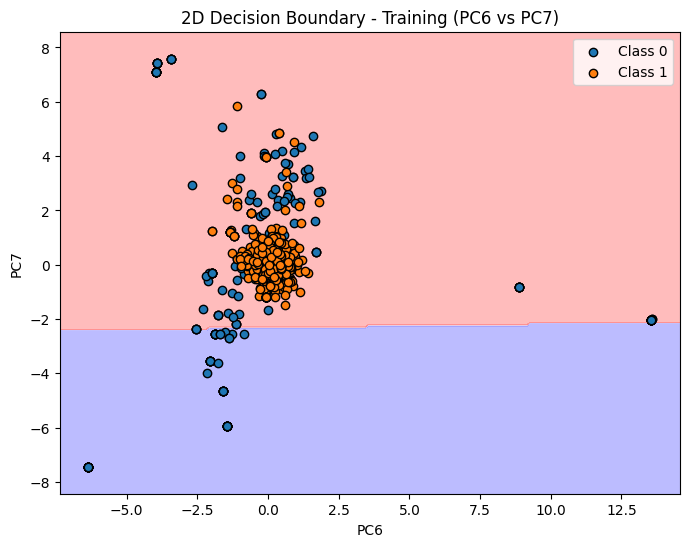

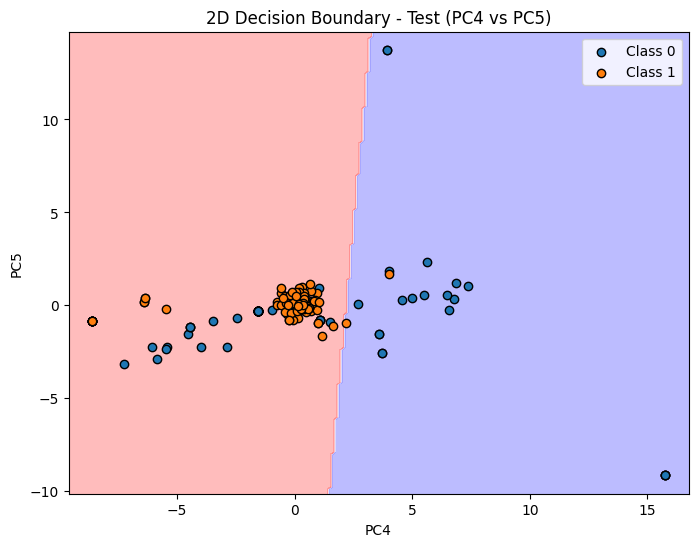

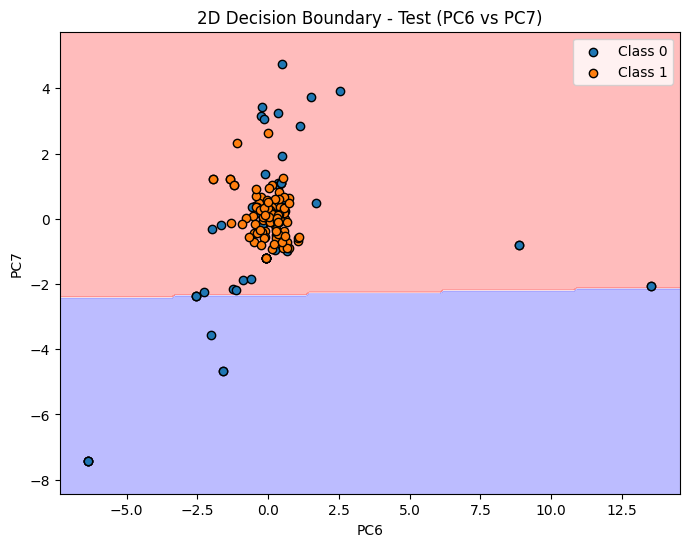

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import plotly.graph_objects as go

y_train = np.ravel(y_train)
y_test = np.ravel(y_test)
# --- PCA on Scaled Data ---
pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# --- Train Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_pca, y_train)

# --- Evaluation ---
print("Train Accuracy:", accuracy_score(y_train, log_reg.predict(X_train_pca)))
print("Test Accuracy:", accuracy_score(y_test, log_reg.predict(X_test_pca)))
print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test, log_reg.predict(X_test_pca)))

# --- Interactive 3D Plot Function ---
def interactive_3d_plot(X_pca, y, model, title):
    coefs = model.coef_[0]
    intercept = model.intercept_[0]

    x_range = np.linspace(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1, 30)
    y_range = np.linspace(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1, 30)
    xx, yy = np.meshgrid(x_range, y_range)
    zz = -(coefs[0] * xx + coefs[1] * yy + intercept) / coefs[2]

    scatter_0 = go.Scatter3d(
        x=X_pca[y == 0, 0], y=X_pca[y == 0, 1], z=X_pca[y == 0, 2],
        mode='markers', marker=dict(size=4, color='red'), name='Class 0'
    )
    scatter_1 = go.Scatter3d(
        x=X_pca[y == 1, 0], y=X_pca[y == 1, 1], z=X_pca[y == 1, 2],
        mode='markers', marker=dict(size=4, color='blue'), name='Class 1'
    )
    plane = go.Surface(
        x=xx, y=yy, z=zz, opacity=0.4, showscale=False, colorscale='gray', name='Decision Plane'
    )

    fig = go.Figure(data=[scatter_0, scatter_1, plane])
    fig.update_layout(
        scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
        title=title,
        width=900, height=700
    )
    fig.show()

# --- 2D Decision Boundary Function ---
def plot_2d_decision_boundary(X, y, model, pc_x, pc_y, title):
    x_min, x_max = X[:, pc_x].min() - 1, X[:, pc_x].max() + 1
    y_min, y_max = X[:, pc_y].min() - 1, X[:, pc_y].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = np.zeros((xx.shape[0], xx.shape[1], 7))
    grid[:, :, pc_x] = xx
    grid[:, :, pc_y] = yy
    Z = model.predict(grid.reshape(-1, 7)).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    for label in np.unique(y):
        plt.scatter(X[y == label, pc_x], X[y == label, pc_y],
                    label=f"Class {label}", edgecolors='k')
    plt.xlabel(f"PC{pc_x+1}")
    plt.ylabel(f"PC{pc_y+1}")
    plt.title(title)
    plt.legend()
    plt.show()

# ========================
# ✅ PLOTS FOR TRAIN DATA
# ========================
interactive_3d_plot(X_train_pca, y_train, log_reg, "Interactive 3D Plot - Training Data (PC1-PC3)")
plot_2d_decision_boundary(X_train_pca, y_train, log_reg, 3, 4, "2D Decision Boundary - Training (PC4 vs PC5)")
plot_2d_decision_boundary(X_train_pca, y_train, log_reg, 5, 6, "2D Decision Boundary - Training (PC6 vs PC7)")

# ========================
# ✅ PLOTS FOR TEST DATA
# ========================
interactive_3d_plot(X_test_pca, y_test, log_reg, "Interactive 3D Plot - Test Data (PC1-PC3)")
plot_2d_decision_boundary(X_test_pca, y_test, log_reg, 3, 4, "2D Decision Boundary - Test (PC4 vs PC5)")
plot_2d_decision_boundary(X_test_pca, y_test, log_reg, 5, 6, "2D Decision Boundary - Test (PC6 vs PC7)")


**Adding the above 3D plots again as 3d plots disppear as soon as we stop editing and save the code for submission**


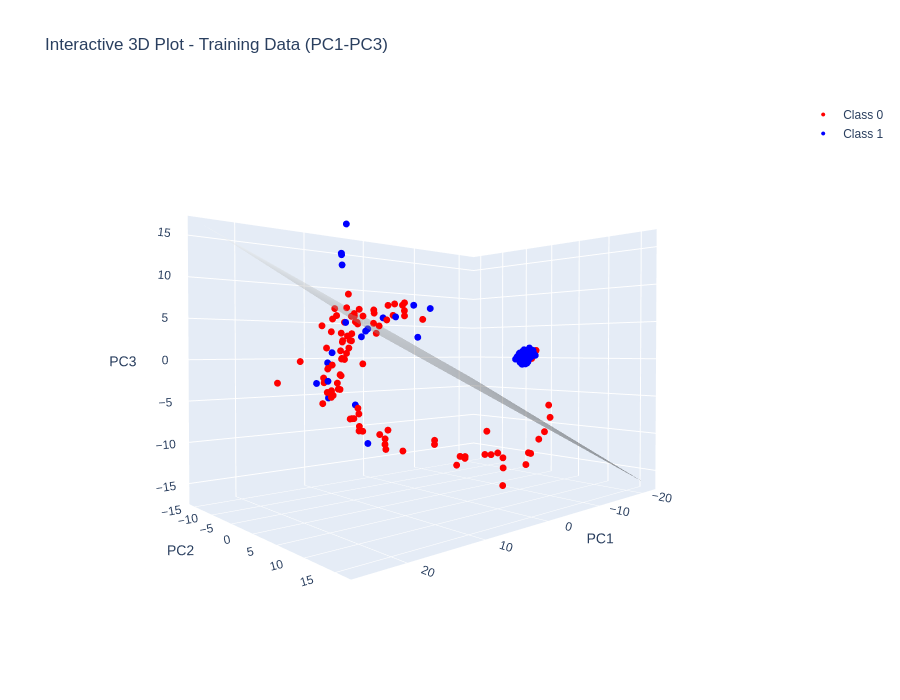
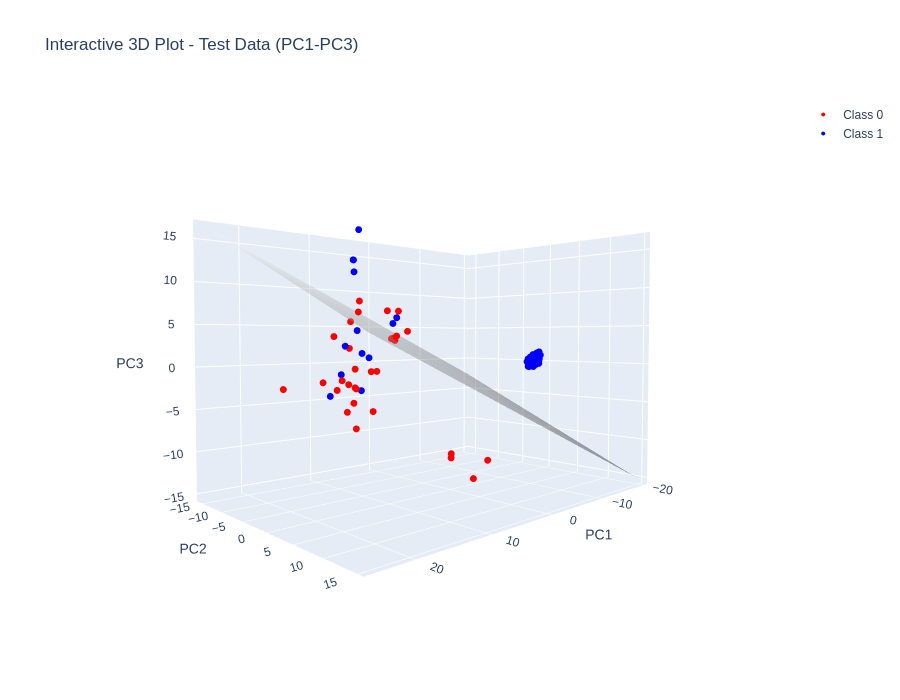




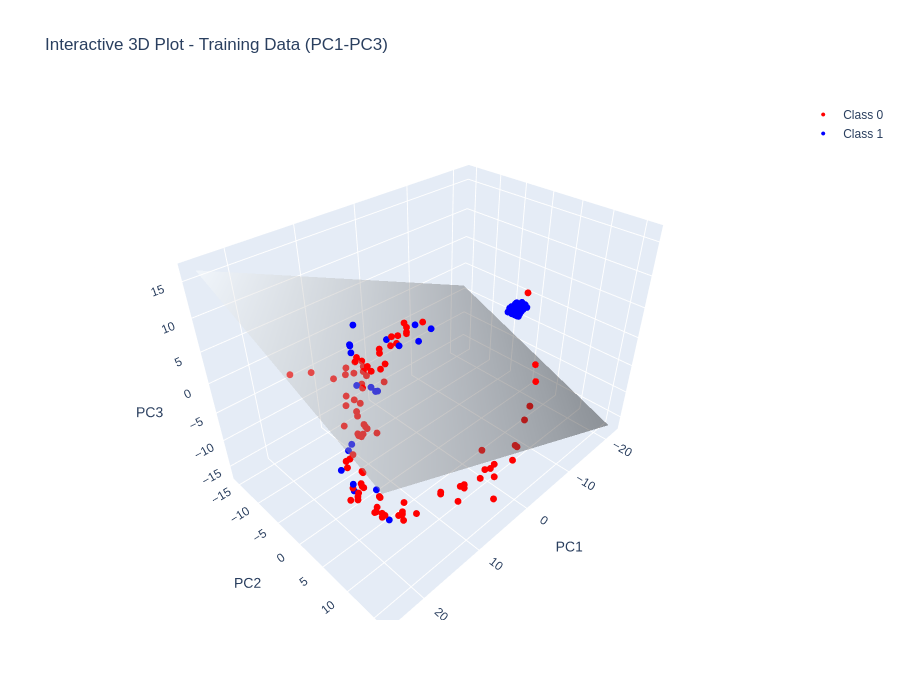
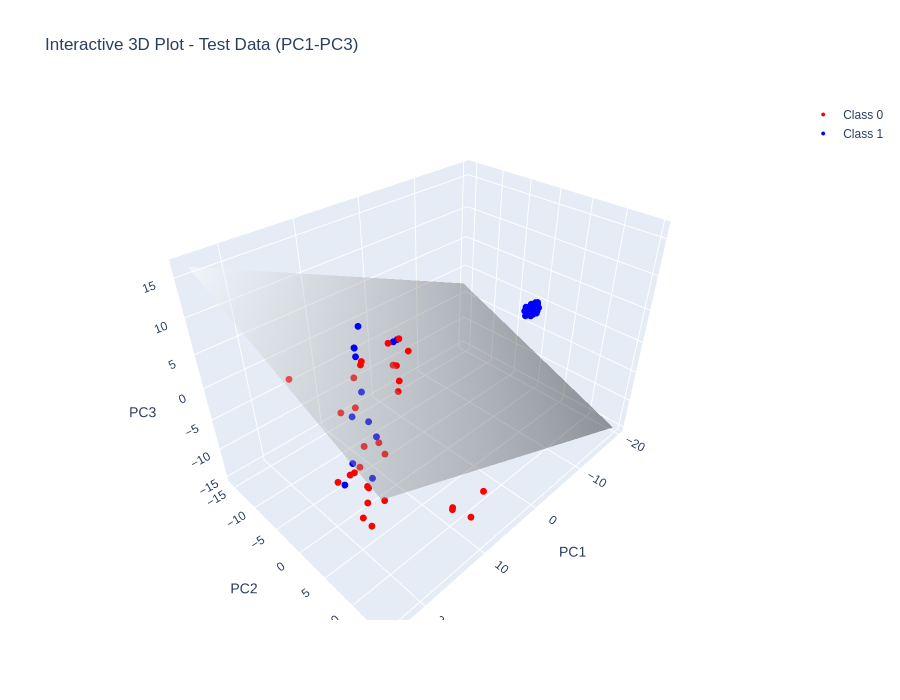